Demo for MPC

In [1]:
# Import the ProblemSolver class and other useful functions
from simopt.experiment_base import (
    ProblemSolver,
    post_normalize,
    plot_progress_curves,
    plot_solvability_cdfs,
    plot_feasibility,
    ProblemsSolvers,
    plot_terminal_progress,
    plot_feasibility_progress

)

In [2]:
from simopt.models.san import SANLongestPathStochastic
from simopt.solvers.fcsa import FCSA
from simopt.solvers.csa_all_solns_unnormalized import CSA as CSA_unnormalized

In [3]:
# initialize problem
initial = (5,)*13 # starting mean for each arc
constraint_nodes = [6,8] #nodes with corresponding stochastic constraints
max_length_to_node = [5, 5] # max expected length to each constraint node
budget = 10000 # number of simmulation replications ran by solver
problem_factors = {"constraint_nodes": constraint_nodes,
                   "length_to_node_constraint": max_length_to_node,
                    "initial_solution": initial, 
                   "budget": budget
}
problem = SANLongestPathStochastic(fixed_factors=problem_factors)
problems = [problem]

In [4]:
# initialize solvers
csa_factors = {"search_direction": "CSA",
               "normalize_grads": False,
               "report_all_solns": True,
               "crn_across_solns": False,
}
csa = FCSA(fixed_factors=csa_factors, name="CSA")
csa_n_factors = {"search_direction": "CSA",
               "normalize_grads": True,
               "report_all_solns": True,
               "crn_across_solns": False,
}
csa_n = FCSA(fixed_factors=csa_n_factors, name="CSA-N")
fcsa_factors = {"search_direction": "FCSA",
               "normalize_grads": True,
               "report_all_solns": True,
               "crn_across_solns": False,
}
fcsa = FCSA(fixed_factors=fcsa_factors, name = "FCSA")
solvers = [csa, csa_n, fcsa]

In [5]:
#initalize experiment
myexperiment = ProblemsSolvers(solvers=solvers, problems=problems)

In [6]:
# Run a fixed number of macroreplications of the solver on the problem.
myexperiment.run(n_macroreps=10)

Running 10 macro-replications of CSA on SAN-2.
Running Solver CSA on Problem SAN-2.
Starting macroreplications in parallel
Finished running 10 macroreplications in 10.886 seconds.
File Name: CSA_on_SAN-2.pickle
Folder Name: C:\Users\nikki\GitHub\stochastic_constraint_tools\experiments\2025-09-07_19-37-07
File Path: C:\Users\nikki\GitHub\stochastic_constraint_tools\experiments\2025-09-07_19-37-07\CSA_on_SAN-2.pickle
Running 10 macro-replications of CSA-N on SAN-2.
Running Solver CSA-N on Problem SAN-2.
Starting macroreplications in parallel
Finished running 10 macroreplications in 11.461 seconds.
File Name: CSA-N_on_SAN-2.pickle
Folder Name: C:\Users\nikki\GitHub\stochastic_constraint_tools\experiments\2025-09-07_19-37-07
File Path: C:\Users\nikki\GitHub\stochastic_constraint_tools\experiments\2025-09-07_19-37-07\CSA-N_on_SAN-2.pickle
Running 10 macro-replications of FCSA on SAN-2.
Running Solver FCSA on Problem SAN-2.
Starting macroreplications in parallel
Finished running 10 macrorepl

In [7]:
# Run a fixed number of postreplications at all recommended solutions.
myexperiment.post_replicate(n_postreps=100)

Post-processing CSA on SAN-2.
Setting up 100 postreplications for 10 macroreplications of CSA on SAN-2.
Starting postreplications in parallel
Finished running 10 postreplications in 13.833 seconds.
File Name: CSA_on_SAN-2.pickle
Folder Name: C:\Users\nikki\GitHub\stochastic_constraint_tools\experiments\2025-09-07_19-37-07
File Path: C:\Users\nikki\GitHub\stochastic_constraint_tools\experiments\2025-09-07_19-37-07\CSA_on_SAN-2.pickle
Post-processing CSA-N on SAN-2.
Setting up 100 postreplications for 10 macroreplications of CSA-N on SAN-2.
Starting postreplications in parallel
Finished running 10 postreplications in 13.469 seconds.
File Name: CSA-N_on_SAN-2.pickle
Folder Name: C:\Users\nikki\GitHub\stochastic_constraint_tools\experiments\2025-09-07_19-37-07
File Path: C:\Users\nikki\GitHub\stochastic_constraint_tools\experiments\2025-09-07_19-37-07\CSA-N_on_SAN-2.pickle
Post-processing FCSA on SAN-2.
Setting up 100 postreplications for 10 macroreplications of FCSA on SAN-2.
Starting pos

In [8]:
# Find an optimal solution x* for normalization.
myexperiment.post_normalize(100)

Postnormalizing on Problem SAN-2.
Finding f(x*)...
	...using best postreplicated solution as proxy for x*.


In [9]:
print(myexperiment.experiments[0][0].solver.name)
print(myexperiment.experiments[1][0].solver.name)
print(myexperiment.experiments)

CSA
CSA-N
[[<simopt.experiment_base.ProblemSolver object at 0x0000029A41FB2A50>], [<simopt.experiment_base.ProblemSolver object at 0x0000029A41F7FB10>], [<simopt.experiment_base.ProblemSolver object at 0x0000029A41F7F890>]]


['C:\\Users\\nikki\\GitHub\\stochastic_constraint_tools\\experiments\\2025-09-07_19-37-07\\plots\\SOLVER_SET_on_SAN-2_terminal_violin (4).png']

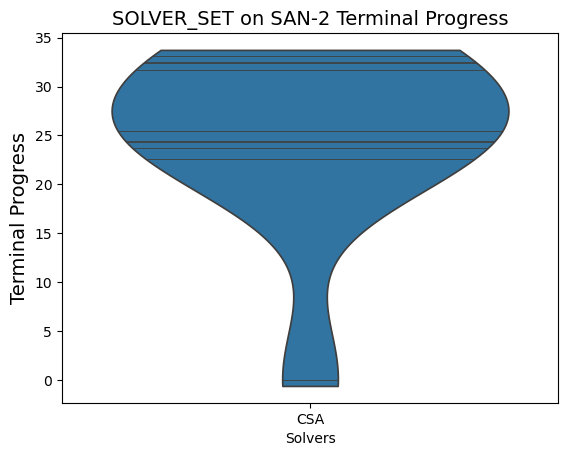

In [19]:
# Plot Figure 2
plot_experiments = myexperiment.experiments[0]
# plot terminal objective density violin plot for csa]
plot_terminal_progress(plot_experiments, "violin", plot_optimal = True)

['C:\\Users\\nikki\\GitHub\\stochastic_constraint_tools\\experiments\\2025-09-07_19-37-07\\plots\\SOLVER_SET_on_SAN-2_feasibility_violin_inf_norm_unnorm (5).png']

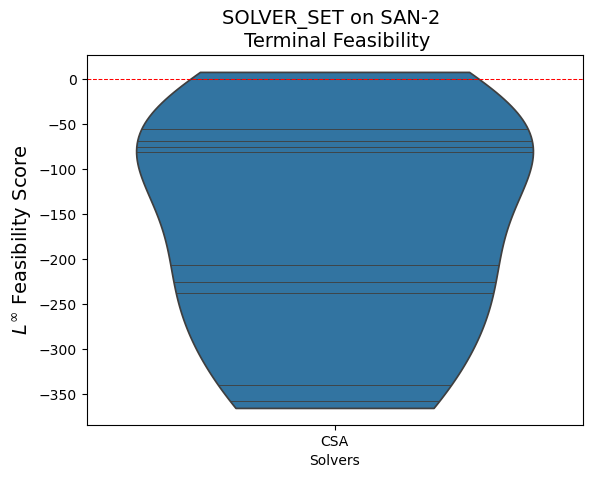

In [18]:
# plot terminal objective density violin plot for csa]
plot_feasibility([plot_experiments], "violin",  all_in_one=True, two_sided=True)

['C:\\Users\\nikki\\GitHub\\stochastic_constraint_tools\\experiments\\2025-09-07_19-37-07\\plots\\SOLVER_SET_on_SAN-2_all_prog_curves_unnorm (1).png']

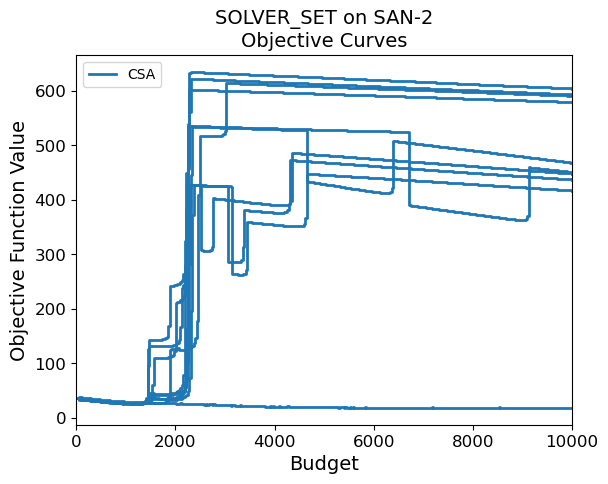

In [20]:
# plot Figure 3
# plot csa objective progress
plot_progress_curves(plot_experiments, "all", normalize=False)
# plot 

['C:\\Users\\nikki\\GitHub\\stochastic_constraint_tools\\experiments\\2025-09-07_19-37-07\\plots\\SOLVER_SET_on_SAN-2_all_prog_curves_unnorm (2).png']

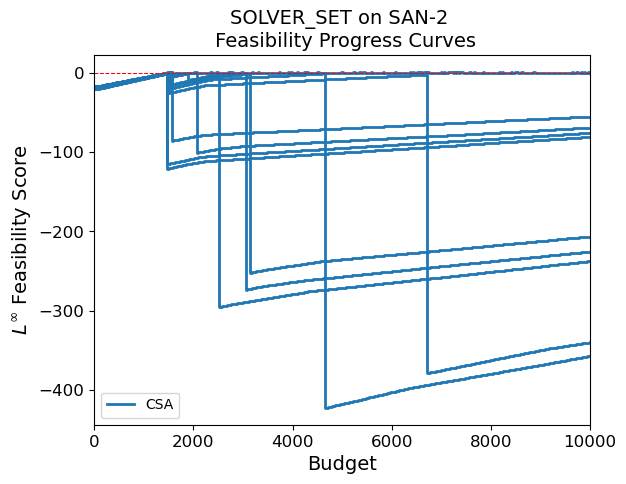

In [24]:
# plot csa feasibility progress
plot_feasibility_progress([plot_experiments], "all", print_max_hw=False)

In [ ]:
# Plot Figure 4
plot_experiments = myexperiment.experiments[1]+myexperiment.experiments[2]